### Bài 1: Xây dựng kiến trúc Encoder-Decoder gồm 3 lớp LSTM cho module encoder và 3 lớp LSTM cho module decoder, với hidden size là 256, cho bài toán dịch máy từ tiếng Anh sang tiếng Việt. Huấn luyện mô hình này trên bộ dữ liệu PhoMT sử dụng Adam làm phương thức tối ưu tham số. Đánh giá độ hiệu quả của mô hình sử dụng độ đo ROUGE-L.

In [130]:
!pip install -q rouge-score

In [131]:
# Import các thư viện cần thiết
import os
import sys
import json

import torch
from typing import List, Dict
import numpy as np

base_dir = os.getcwd()
# data_dir = os.path.join(base_dir, 'data', 'small_subset')
colab_dir = os.path.join(base_dir)

# Đọc train/dev/test small subset data
train_data = json.load(open(os.path.join(colab_dir, 'small-train.json'), 'r', encoding='utf-8'))
dev_data = json.load(open(os.path.join(colab_dir, 'small-dev.json'), 'r', encoding='utf-8'))
test_data = json.load(open(os.path.join(colab_dir, 'small-test.json'), 'r', encoding='utf-8'))

print("\nSample train:")
print(type(train_data))
print(train_data[0])


Sample train:
<class 'list'>
{'english': 'It begins with a countdown .', 'vietnamese': 'Câu chuyện bắt đầu với buổi lễ đếm ngược .'}


## 1. Tiền xử lý dữ liệu + TOKENIZE + BUILD VOCAB

In [132]:
import re

def clean_text(text: str):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # bỏ dấu câu
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [133]:
def tokenize(sentence: str):
    """
    Tokenize đơn giản: lowercase + split theo khoảng trắng
    """
    sentence = clean_text(sentence)
    return sentence.split()

In [134]:
print(tokenize("Hello, world! How are you?"))

['hello', 'world', 'how', 'are', 'you']


In [135]:
# Kiểm tra hàm tokenize theo split whitespace và lowercase
print(tokenize(train_data[0]["english"]))
print(tokenize(train_data[0]["vietnamese"]))

['it', 'begins', 'with', 'a', 'countdown']
['câu', 'chuyện', 'bắt', 'đầu', 'với', 'buổi', 'lễ', 'đếm', 'ngược']


### 1.1 Thu thập token từ toàn bộ train set

In [136]:
from collections import Counter

# Counter là một dict đặc biệt để đếm tần số xuất hiện của các phần tử trong một iterable
src_counter = Counter() # src: source language (English)
tgt_counter = Counter() # tgt: target language (Vietnamese)

for sample in train_data:
    src_tokens = tokenize(sample["english"])
    tgt_tokens = tokenize(sample["vietnamese"])

    # Cập nhật counter với các token từ câu hiện tại
    src_counter.update(src_tokens)
    tgt_counter.update(tgt_tokens)

print("Số token tiếng Anh (raw):", len(src_counter))
print("Số token tiếng Việt (raw):", len(tgt_counter))

Số token tiếng Anh (raw): 17252
Số token tiếng Việt (raw): 6883


In [137]:
print(src_counter.most_common(5))  # 10 token xuất hiện nhiều nhất trong tập tiếng Anh
print(tgt_counter.most_common(5))  # 10 token xuất hiện nhiều nhất trong tập tiếng Việt

[('the', 15553), ('and', 10979), ('to', 9490), ('of', 8577), ('a', 7837)]
[('và', 9062), ('tôi', 8797), ('là', 8127), ('có', 7399), ('một', 6995)]


### 1.2 Định nghĩa các special tokens

>`eos` đặc biệt cần thiết trong seq2seq khi đánh giá bằng ROUCE-L - vì không có nó, thành phần precision sẽ giảm mạnh do cố gắng sinh thừa từ.

>`bos` sẽ ảnh hưởng nhẹ hơn, nhưng vẫn cần có nó vì nếu không, timestep đầu rất dễ đoán sai, mà LSTM lại phụ thuộc rất nhiều vào hidden_state của step trước.

In [138]:
PAD_TOKEN = "<pad>" # padding 0, cho câu ngắn
BOS_TOKEN = "<bos>" # begin of sentence - Bắt đầu sinh
EOS_TOKEN = "<eos>" # end of sentence - Kết thúc sinh =>
UNK_TOKEN = "<unk>" # unknown token - từ không có trong tập từ điển

SPECIAL_TOKENS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

### 1.3 Build vocab với `min_freq = 2`

Theo thống kê thì: Phân phối từ vựng xuất hiện nhiều từ hiếm (xuất hiện <1 lần), đặc biệt ở tiếng Anh, ta sẽ áp dụng ngưỡng tần suất tối thiểu khi xây dựng tập từ điển. Cụ thể, min_freq = 2 được sử dụng cho cả hai ngôn ngữ nhằm giảm kích thước từ vựng và hạn chế nhiễu từ các từ hiếm. `Xem chi tiết tại file EDA_PhoMT.ipynb`

English:

- Total vocab: 17414
- Tokens with freq ≤ 1: 7334 (42.12%)
- Tokens with freq ≤ 2: 10016 (57.52%)
- Tokens with freq ≤ 5: 13138 (75.45%)

Vietnamese:

- Total vocab: 7057
- Tokens with freq ≤ 1: 2749 (38.95%)
- Tokens with freq ≤ 2: 3612 (51.18%)
- Tokens with freq ≤ 5: 4543 (64.38%)

In [139]:
def build_vocab(counter, min_freq=2):
    '''
    Build vocabulary từ counter với ngưỡng min_freq
    Input:
        counter: 1 instance Counter đếm tần số token
        min_freq: ngưỡng tần số tối thiểu để token được thêm vào vocab
    Output:
        vocab: list các token trong vocabulary
        token2id: dict mapping token => id
        id2token: dict mapping id => token
    '''
    vocab = SPECIAL_TOKENS.copy()

    for token, freq in counter.items():
        if freq >= min_freq: # mặc định min_freq=2
            vocab.append(token)

    # Tạo mapping token <=> id
    token2id = {token: idx for idx, token in enumerate(vocab)}

    # Tạo mapping id <=> token
    id2token = {idx: token for token, idx in token2id.items()}

    return vocab, token2id, id2token

In [140]:
# Xây dựng vocab + mapping w2i và i2w cho cả 2 ngôn ngữ
src_vocab, src_token2id, src_id2token = build_vocab(src_counter, min_freq=2)
tgt_vocab, tgt_token2id, tgt_id2token = build_vocab(tgt_counter, min_freq=2)

src_vocab[:10] # 10 token đầu trong vocab tiếng Anh

['<pad>',
 '<bos>',
 '<eos>',
 '<unk>',
 'it',
 'begins',
 'with',
 'a',
 'on',
 'august']

In [141]:
# Kiểm tra dạng lưu trữ của token2id và id2token
print(type(src_token2id), type(src_id2token))
print(list(src_token2id.items())[:10])  # 10 mapping token => id đầu tiên
print(list(src_id2token.items())[:10])  # 10 mapping id => token

<class 'dict'> <class 'dict'>
[('<pad>', 0), ('<bos>', 1), ('<eos>', 2), ('<unk>', 3), ('it', 4), ('begins', 5), ('with', 6), ('a', 7), ('on', 8), ('august', 9)]
[(0, '<pad>'), (1, '<bos>'), (2, '<eos>'), (3, '<unk>'), (4, 'it'), (5, 'begins'), (6, 'with'), (7, 'a'), (8, 'on'), (9, 'august')]


In [142]:
print("SRC vocab size:", len(src_vocab))
print("TGT vocab size:", len(tgt_vocab))

SRC vocab size: 10025
TGT vocab size: 4253


>Ta thấy giảm đáng kể vocab size:
- Số token tiếng Anh (raw): 17414 còn 10084
- Số token tiếng Việt (raw): 7057 còn 4312

=> Ta chấp nhận sự đánh đổi này, vì mô hình sẽ đỡ nặng hơn và đỡ học phải nhiễu (Xem thêm tại file EDA_PhoMT.ipynb)

### 1.4 Mapping câu => sequence id (chưa padding)

In [143]:
def numericalize(tokens: List[str], token2id: Dict[str, int]) -> List[int]:
    '''
    Chuyển danh sách token thành danh sách id tương ứng:
    Input:
        tokens: list các token
        token2id: dict mapping token => id
    Output:
        list các id tương ứng với token
    '''
    return [
        token2id.get(token, token2id[UNK_TOKEN])
        for token in tokens
    ]

In [144]:
sample = train_data[0]

# Chuyển câu sample sang dạng id
src_ids = numericalize(tokenize(sample["english"]), src_token2id)
tgt_ids = numericalize(tokenize(sample["vietnamese"]), tgt_token2id)

print("Sample sentence (ENG):", sample["english"])
print("SRC ids:", src_ids)

print("Sample sentence (VIE):", sample["vietnamese"])
print("TGT ids:", tgt_ids)

Sample sentence (ENG): It begins with a countdown .
SRC ids: [4, 5, 6, 7, 3]
Sample sentence (VIE): Câu chuyện bắt đầu với buổi lễ đếm ngược .
TGT ids: [4, 5, 6, 7, 8, 9, 10, 11, 12]


## 2. PADDING + DATASET + DATALOADER

In [145]:
MAX_SRC_LEN = 70 # Xem file EDA_PhoMT.ipynb
MAX_TGT_LEN = 85 # Xem file EDA_PhoMT.ipynb

PAD_ID = src_token2id[PAD_TOKEN]
BOS_ID = tgt_token2id[BOS_TOKEN]
EOS_ID = tgt_token2id[EOS_TOKEN]
UNK_ID = tgt_token2id[UNK_TOKEN]

print(PAD_ID, BOS_ID, EOS_ID, UNK_ID)

0 1 2 3


### 2.1 Padding và truncate sequence

In [146]:
def pad_sequence(seq: List[int], max_len: int, pad_id: int) -> List[int]:
    """
    Right-padding hoặc truncate sequence
    Input:
        seq: list các id (int)
        max_len: độ dài tối đa của sequence sau khi padding/truncate
        pad_id: id dùng để padding
    Return:
        list các id có độ dài = max_len
    """
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_id] * (max_len - len(seq))

In [147]:
# Ví dụ pad/truncate
sample = train_data[0]
src_ids = numericalize(tokenize(sample["english"]), src_token2id)
tgt_ids = numericalize(tokenize(sample["vietnamese"]), tgt_token2id)

print("Original SRC ids length:", len(src_ids))
padded_src_ids = pad_sequence(src_ids, MAX_SRC_LEN, PAD_ID)
print("Padded SRC ids length:", len(padded_src_ids))

print("Original TGT ids length:", len(tgt_ids))
padded_tgt_ids = pad_sequence(tgt_ids, MAX_TGT_LEN, PAD_ID)
print("Padded TGT ids length:", len(padded_tgt_ids))

Original SRC ids length: 5
Padded SRC ids length: 70
Original TGT ids length: 9
Padded TGT ids length: 85


### 2.2 Xử lý target sequence

In [148]:
def process_target(tokens: List[str], token2id: Dict[str, int], max_len: int) -> List[int]:
    """
    Xử lý target sequence: thêm BOS/EOS, numericalize, pad/truncate
    Input:
        tokens: list các token (str)
        token2id: dict mapping token => id
        max_len: độ dài tối đa của sequence sau khi padding/truncate
    Return:
        list các id có độ dài = max_len
     <bos> w1 w2 ... wn <eos>
    """
    ids = [BOS_ID] + numericalize(tokens, token2id) + [EOS_ID]
    return pad_sequence(ids, max_len, PAD_ID)

### 2.3 Tạo Dataset và DataLoader

In [149]:
import torch
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    '''
    PyTorch Dataset cho bài toán dịch máy tiếng Anh sang tiếng Việt.
    '''
    def __init__(self, data, src_token2id, tgt_token2id):
        self.data = data # list các sample, mỗi sample là dict {"english": ..., "vietnamese": ...}
        self.src_token2id = src_token2id
        self.tgt_token2id = tgt_token2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Lấy một sample đã được tokenize, numericalize và padding.

        Input:
            idx (int): chỉ số của sample

        Output:
            dict:
                "src": LongTensor (MAX_SRC_LEN,)
                "tgt": LongTensor (MAX_TGT_LEN,)
        """
        sample = self.data[idx]

        # Source
        src_tokens = tokenize(sample["english"])
        src_ids = numericalize(src_tokens, self.src_token2id)
        src_ids = pad_sequence(src_ids, MAX_SRC_LEN, PAD_ID)

        # Target
        tgt_tokens = tokenize(sample["vietnamese"])
        tgt_ids = process_target(tgt_tokens, self.tgt_token2id, MAX_TGT_LEN)
        # Chỉ có target mới cần thêm BOS/EOS bằng hàm process_target - vì nó dùng để sinh câu - Decoding

        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "tgt": torch.tensor(tgt_ids, dtype=torch.long)
        }

In [150]:
from torch.utils.data import DataLoader

train_dataset = TranslationDataset(train_data, src_token2id, tgt_token2id)
dev_dataset   = TranslationDataset(dev_data, src_token2id, tgt_token2id)
test_dataset  = TranslationDataset(test_data, src_token2id, tgt_token2id)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=64,
    shuffle=False
)

In [151]:
# Kiểm tra thử
batch = next(iter(train_loader))
print(batch["src"].shape)  # [32, 70]
print(batch["tgt"].shape)  # [32, 85]

print(batch["tgt"][0])

torch.Size([64, 70])
torch.Size([64, 85])
tensor([  1, 412, 906, 403, 212, 394, 319, 444, 311, 374, 416, 346, 347, 750,
        906, 403, 534, 117, 311, 705, 444,   2,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0])


>`bos = 1` | `eos = 2` | `padding = 0`

## 3. MODEL ENCODER–DECODER LSTM

English ids
=> Embedding (256)
=> Encoder LSTM (3 layers, hidden=256)
=> hidden, cell
=> Decoder LSTM (3 layers, hidden=256)
=>  Linear
=>  Vietnamese vocab logits


### 3.1 Encoder 3-layer LSTM

In [152]:
import torch.nn as nn

class Encoder(nn.Module):
    """
    Encoder LSTM cho bài toán dịch máy.

    Input:
        src: Tensor shape (batch_size, src_len)
    Output:
        hidden, cell: Tensor shape (num_layers, batch_size, hidden_size)
    """

    def __init__(self, vocab_size, embed_dim=256, hidden_size=256, num_layers=3):
        super().__init__()

        # Layer 1: Embedding
        # Chuyển word indices (số nguyên) thành vector ngữ nghĩa liên tục
        # (ví dụ chữ cat được encode là 31, thì embedding sẽ chuyển 31 thành vector liên tục có chiều dài là embedding_dim)
        # Input: [batch_size, seq_len] → Output: [batch_size, seq_len, embedding_dim]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, # Số từ trong vocab
            embedding_dim=embed_dim, # Chiều dài embedding
            padding_idx=PAD_ID # ID dùng để padding - thường là 0
        )

        # Layer 2: LSTM
        # Xử lý tuần tự các embedding vectors
        # Input: [batch_size, seq_len, embedding_dim] - có được từ layer Embedding
        # Output: [batch_size, seq_len, hidden_size] (nếu return_sequences=True)
        # Hidden/Cell: [num_layers, batch_size, hidden_size]
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, src):
        # src: [batch_size, seq_len] - 1 vector (batch_size) of word indices (biểu diễn số của từng từ trong câu)
        embedded = self.embedding(src)          # (B, src_len, 256)
        # print(f"[Encoder] After embedding: {embedded.shape}")
        # Output shape: [batch_size, seq_len, embed_dim]

        outputs, (hidden, cell) = self.lstm(embedded)
        # outputs:
        #   Hidden states của LSTM tại TẤT CẢ timesteps,
        #   nhưng CHỈ của layer trên cùng (top layer)
        #   Shape: (batch_size, src_len, hidden_size)

        # hidden:
        #   Hidden state tại timestep CUỐI CÙNG của MỖI layer
        #   Shape: (num_layers, batch_size, hidden_size)

        # cell:
        #   Cell state (long-term memory) tại timestep CUỐI CÙNG của MỖI layer
        #   Shape: (num_layers, batch_size, hidden_size)

        # print(f"[Encoder] After LSTM - output: {outputs.shape}, hidden: {hidden.shape}")

        # Return hidden & cell state
        # Cái này sẽ dùng làm initial state cho Decoder
        return hidden, cell

### 3.2 Decoder 3-layer LSTM

In [153]:
class Decoder(nn.Module):
    """
    Decoder LSTM cho bài toán dịch máy.

    Input:
        input_token: Tensor shape (batch_size, 1)
        hidden, cell: từ Encoder hoặc timestep trước
    Output:
        logits: Tensor shape (batch_size, vocab_size)

        Cấu trúc:
        Từ trước đó (token)
            ↓ [Embedding Layer]
        Embedding vector
            ↓ [LSTM] (sử dụng hidden/cell từ Encoder)
        Output vector
            ↓ [Linear Layer]
        Logits của từ tiếp theo

    """

    def __init__(self, vocab_size, embed_dim=256, hidden_size=256, num_layers=3):
        super().__init__()

        # Layer 1: Embedding
        # Ta cần nó ở đây để chuyển từ trước đó (token) sang embedding vector
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=PAD_ID
        )

        # Layer 2: LSTM
        # Giống như Encoder, nhưng sử dụng initial state từ Encoder
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Layer 3: Linear layer - dự đoán từ tiếp theo
        # Input: hidden_size → Output: vocab_size (logits cho mỗi từ)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_token, hidden, cell):
        """
        Input:
            input_token: [batch_size, 1] - 1 token (thường từ <bos> - begin of sentence hoặc từ trước)
            hidden: [num_layers, batch_size, hidden_size] - từ Encoder
            cell: [num_layers, batch_size, hidden_size] - từ Encoder

        Returns:
            prediction: [batch_size, vocab_size] - logits của từ tiếp theo - logit là xác suất
            hidden: [num_layers, batch_size, hidden_size] - hidden state mới
            cell: [num_layers, batch_size, hidden_size] - cell state mới
        """

        # Bước 1: Embedding - Input: [batch_size, 1] → Output: [batch_size, 1, embed_dim]
        embedded = self.embedding(input_token)
        # print(f"[Decoder] After embedding: {embedded.shape}") # (Batch_size, 1, 256)

        # Bước 2: LSTM
        # Input: [batch_size, 1, embed_dim] + hidden/cell từ Encoder
        # Output:
            # output [batch_size, 1, hidden_size]
            # hidden [num_layers, batch_size, hidden_size]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # print(f"[Decoder] After LSTM - output: {output.shape}, hidden: {hidden.shape}")
        # output: (Batch_size, 1, 256)
        # hidden: (num_layers, Batch_size, 256)

        logits = self.fc_out(output.squeeze(1))  # squeeze để bỏ chiều 1 bị thừa - (B, vocab_size)
        # print(f"[Decoder] After linear: {logits.shape}")

        return logits, hidden, cell

### 3.3 Seq2Seq wrapper ghép Encoder + Decoder

In [154]:
class Seq2Seq(nn.Module):
    """
    Mô hình Seq2Seq đơn giản: Encoder + Decoder

    - Encoder đọc toàn bộ câu nguồn
    - Decoder sinh câu đích từng bước (auto-regressive)
    - Có hỗ trợ teacher forcing khi huấn luyện
    """

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Args:
            src: Tensor shape (batch_size, src_len)
                 Câu nguồn (tiếng Anh)
            tgt: Tensor shape (batch_size, tgt_len)
                 Câu đích (tiếng Việt), đã có <bos> ở đầu
            teacher_forcing_ratio: xác suất dùng token đúng làm input cho decoder

        Returns:
            outputs: Tensor shape (batch_size, tgt_len - 1, vocab_size)
                     Logits cho mỗi timestep
        """
        batch_size = src.size(0)
        tgt_len = tgt.size(1) # tgt_len là độ dài cố định của target sequence, đã bao gồm <bos>, <eos> và padding.
        vocab_size = self.decoder.fc_out.out_features
        # print(f"Seq2Seq forward - batch_size: {batch_size}, tgt_len: {tgt_len}, vocab_size: {vocab_size}")
        outputs = []

        # STEP 1: Encoder
        # print("\n=== ENCODER ===")
        hidden, cell = self.encoder(src)
        # print(f"Encoder outputs - hidden: {hidden.shape}, cell: {cell.shape}")

        # STEP 2: Decoder
        # Input đầu tiên cho decoder là <bos>
        # print("\n=== DECODER ===")
        decoder_input = tgt[:, 0].unsqueeze(1)  # (B, 1)

        # Sinh từng token
        for t in range(1, tgt_len):
            # Dự đoán token tại timestep t
            # print(f"Decoding timestep {t}...")
            # print(f"  Input: {decoder_input.shape}")

            prediction, hidden, cell = self.decoder(
                decoder_input, hidden, cell
            )
            outputs.append(prediction.unsqueeze(1))
            # print(f"  Prediction: {prediction.shape} (logits)")

            # Teacher forcing
            if np.random.random() < teacher_forcing_ratio:
                # Dùng token đúng
                decoder_input = tgt[:, t].unsqueeze(1)
            else:
                # Dùng token model dự đoán
                top_token = prediction.argmax(dim=1)
                decoder_input = top_token.unsqueeze(1)

        # Ghép logits của tất cả timestep
        outputs = torch.cat(outputs, dim=1)
        # print(f"\nFinal outputs shape: {outputs.shape}")

        return outputs

**Lưu ý: Trong vòng lặp:**

```python
for t in range(1, tgt_len):
```

**Timestep cuối cùng (t = tgt_len - 1)**
model đang **học dự đoán token nào?**
Là `<eos>` hay `<pad>`? và **điều đó có vấn đề gì không?**

=> Trả lời: model đang dự đoán token `<pad>` vì lúc này ở phần cuối của tgt, `<eos>` đã là token ở các step trước đó

Ví dụ: [`<bos>`, w1, w2, w3, w4, `<eos>`, `<pad>`, `<pad>`, `<pad`>, `<pad>`] tgt_len = 10


In [155]:
SRC_VOCAB_SIZE = len(src_token2id)
TGT_VOCAB_SIZE = len(tgt_token2id)

encoder = Encoder(SRC_VOCAB_SIZE)
decoder = Decoder(TGT_VOCAB_SIZE)

model = Seq2Seq(encoder, decoder)

batch = next(iter(train_loader))
out = model(batch["src"], batch["tgt"])

print(out.shape)
# expected: (32, 84, TGT_VOCAB_SIZE)


torch.Size([64, 84, 4253])


## 4. TRAINING LOOP (Seq2Seq + Adam)

### 4.1 Chuẩn bị loss & optimizer

In [156]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

> Lưu ý quan trọng: ignore `<pad>` là bắt buộc. Nếu không, model sinh `<pad>` sớm => câu toàn kí tự `<pad>` => ROUGE-L tụt (do thành phần LCS prediction + recall tụt). Do thông thường kí hiệu `<pad>` xuất hiện rất nhiều - do câu ngắn chiếm đa số (ngắn hơn tgt_len), nếu không ignore `<pad>`, model sẽ cố gắng an toàn sinh ra toàn các `<pad>` sớm, gây mất nhiều từ quan trọng và câu bị ngắn đi.

### 4.2 Hàm train 1 epoch

In [157]:
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    teacher_forcing_ratio=0.5,
    device="cpu"
):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        src = batch["src"].to(device)  # (B, src_len)
        tgt = batch["tgt"].to(device)  # (B, tgt_len)

        optimizer.zero_grad()

        # Forward
        outputs = model(
            src,
            tgt,
            teacher_forcing_ratio=teacher_forcing_ratio
        )
        # outputs: (B, tgt_len-1, vocab_size)

        # ===== LOSS =====
        # Dự đoán: outputs[:, t] ↔ target: tgt[:, t+1]
        output_dim = outputs.size(-1)

        outputs = outputs.reshape(-1, output_dim)
        targets = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)

        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

- `tgt[:, 1:]` là label

- `<bos>` không được tính loss

- `<pad>` bị ignore

### 4.3 Hàm validation (KHÔNG teacher forcing)

In [158]:
@torch.no_grad()
def evaluate(
    model,
    dataloader,
    criterion,
    device="cpu"
):
    model.eval()
    total_loss = 0.0

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        # teacher_forcing_ratio = 0.0
        outputs = model(src, tgt, teacher_forcing_ratio=0.0)

        output_dim = outputs.size(-1)

        outputs = outputs.reshape(-1, output_dim)
        targets = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)
        total_loss += loss.item()

    return total_loss / len(dataloader)

## 4.4 Hàm tính ROUGE-L

In [159]:
from rouge_score import rouge_scorer
from tqdm import tqdm

def evaluate_rouge_l(model, dataloader, id2token, device="cpu"):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

    scores = []

    for batch in tqdm(dataloader):
        src = batch["src"]
        tgt = batch["tgt"]

        pred_ids = translate_batch(model, src, device=device)

        for i in range(len(pred_ids)):
            pred_sent = decode_sentence(pred_ids[i], id2token)
            ref_sent = decode_sentence(
                tgt[i][1:].tolist(),  # bỏ <bos>
                id2token
            )

            score = scorer.score(ref_sent, pred_sent)["rougeL"].fmeasure
            scores.append(score)

    return sum(scores) / len(scores)

### 4.4 Training loop tổng

In [160]:
best_val_loss = float("inf")
BEST_MODEL_PATH = "best_seq2seq_model.pt"

In [161]:
import time

train_losses = []
val_losses = []

N_EPOCHS = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for epoch in range(1, N_EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        teacher_forcing_ratio=0.5,
        device=device
    )

    val_loss = evaluate(
        model,
        dev_loader,
        criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # LƯU MODEL TỐT NHẤT
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        improved = "saved"
    else:
        improved = ""

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch:02d}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val   loss: {val_loss:.4f} {improved}")
    print(f"  Time  : {epoch_time:.2f} sec")

Epoch 01
  Train loss: 6.3539
  Val   loss: 6.4018 saved
  Time  : 63.30 sec
Epoch 02
  Train loss: 6.1826
  Val   loss: 6.3767 saved
  Time  : 62.76 sec
Epoch 03
  Train loss: 5.9908
  Val   loss: 6.3690 saved
  Time  : 62.63 sec
Epoch 04
  Train loss: 5.8541
  Val   loss: 6.3473 saved
  Time  : 63.36 sec
Epoch 05
  Train loss: 5.7517
  Val   loss: 6.3232 saved
  Time  : 62.90 sec
Epoch 06
  Train loss: 5.6391
  Val   loss: 6.3005 saved
  Time  : 62.64 sec
Epoch 07
  Train loss: 5.5385
  Val   loss: 6.2287 saved
  Time  : 63.28 sec
Epoch 08
  Train loss: 5.4321
  Val   loss: 6.1999 saved
  Time  : 62.75 sec
Epoch 09
  Train loss: 5.3305
  Val   loss: 6.1760 saved
  Time  : 62.70 sec
Epoch 10
  Train loss: 5.2599
  Val   loss: 6.1418 saved
  Time  : 62.60 sec
Epoch 11
  Train loss: 5.1926
  Val   loss: 6.1267 saved
  Time  : 63.64 sec
Epoch 12
  Train loss: 5.1291
  Val   loss: 6.1121 saved
  Time  : 62.69 sec
Epoch 13
  Train loss: 5.0575
  Val   loss: 6.1063 saved
  Time  : 62.77 sec


## Vì sao training **chậm dù GPU chỉ ăn ~1.3GB**?

**GPU RAM thấp ≠ GPU đang được dùng hiệu quả**

### Nguyên nhân CHÍNH: Seq2Seq LSTM hiện code **không song song theo timestep**

Nhìn lại forward:

```python
for t in range(1, tgt_len):
    prediction, hidden, cell = self.decoder(...)
```

Đây là **vòng for Python-level**

* Mỗi timestep:

  * gọi LSTM
  * sync CPU ↔ GPU
* Với `tgt_len = 85`:

  * **85 lần forward decoder / batch**
* GPU phải **chờ CPU ra lệnh liên tục**

In [162]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

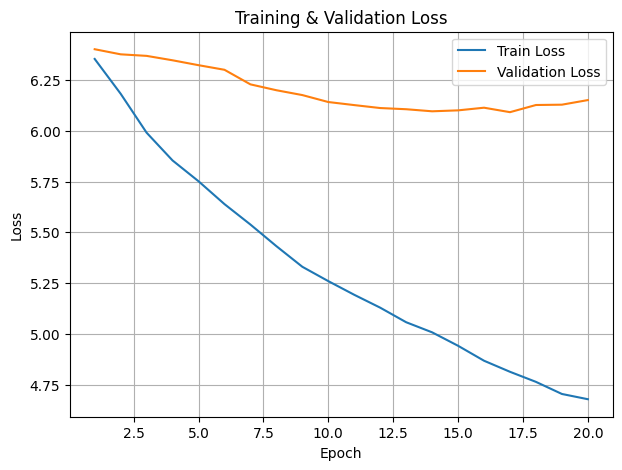

In [163]:
plot_losses(train_losses, val_losses)

## 5. Inference + ROUGE-L evaluation

In [164]:
model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)
model = model.to(device)
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10025, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=3, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(4253, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=3, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=4253, bias=True)
  )
)

### 5.1 INFERENCE (GREEDY DECODING)

In [165]:
@torch.no_grad()
def translate_batch(model, src, max_tgt_len=MAX_TGT_LEN, device="cpu"):
    """
    Input:
        src: Tensor (B, src_len)
    Output:
        predictions: List[List[int]]  # token ids
    """
    model.eval()
    src = src.to(device)

    hidden, cell = model.encoder(src)

    batch_size = src.size(0)
    decoder_input = torch.full(
        (batch_size, 1),
        BOS_ID,
        dtype=torch.long,
        device=device
    )

    predictions = [[] for _ in range(batch_size)]

    for _ in range(max_tgt_len):
        logits, hidden, cell = model.decoder(decoder_input, hidden, cell)
        next_token = logits.argmax(dim=1)  # (B,)

        decoder_input = next_token.unsqueeze(1)

        for i in range(batch_size):
            predictions[i].append(next_token[i].item())

    return predictions

In [166]:
def decode_sentence(token_ids, id2token):
    tokens = []
    for idx in token_ids:
        if idx == EOS_ID:
            break
        if idx != PAD_ID:
            tokens.append(id2token.get(idx, UNK_TOKEN))
    return " ".join(tokens)

In [167]:
batch = next(iter(dev_loader))
pred_ids = translate_batch(model, batch["src"], device=device)

print("PRED:", decode_sentence(pred_ids[0], tgt_id2token))
print("REF :", decode_sentence(batch["tgt"][0][1:].tolist(), tgt_id2token))

PRED: hầu hết những người một một một một một một một một một một một một một một một một một một một một trong một trong những một và và và và và và và và và và và và và và một người
REF : vào chủ nhật ngày <unk> cơn bão <unk> một trong những cơn bão mạnh nhất được ghi nhận ở đại tây dương với sức gió <unk> <unk> đổ bộ vào đảo great <unk> miền bắc <unk>


>Rất tệ

In [168]:
rouge_l = evaluate_rouge_l(
    model,
    dev_loader,
    tgt_id2token,
    device=device
)

print(f"ROUGE-L (dev): {rouge_l:.4f}")

100%|██████████| 32/32 [00:05<00:00,  6.08it/s]

ROUGE-L (dev): 0.2902


ROUGE-L (dev): 0.2902 - Khá tệ, nhưng do dữ liệu training đã cắt ngắn, nên kết quả này có thể chấp nhận được.

### 5.2 Test trên test set

In [169]:
test_dataset = TranslationDataset(
    test_data,
    src_token2id,
    tgt_token2id
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [170]:
model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)
model = model.to(device)
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10025, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=3, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(4253, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=3, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=4253, bias=True)
  )
)

In [171]:
test_loss = evaluate(
    model,
    test_loader,
    criterion,
    device=device
)

print(f"Test loss: {test_loss:.4f}")

Test loss: 6.0589


In [172]:
test_rouge_l = evaluate_rouge_l(
    model,
    test_loader,
    tgt_id2token,
    device=device
)

print(f"ROUGE-L (test): {test_rouge_l:.4f}")

100%|██████████| 63/63 [00:05<00:00, 10.50it/s]

ROUGE-L (test): 0.2960


>test đạt 0.2960

In [173]:
batch = next(iter(test_loader))
pred_ids = translate_batch(model, batch["src"], device=device)

for i in range(3):
    print("SRC :", decode_sentence(batch["src"][i].tolist(), src_id2token))
    print("REF :", decode_sentence(batch["tgt"][i][1:].tolist(), tgt_id2token))
    print("PRED:", decode_sentence(pred_ids[i], tgt_id2token))
    print("-" * 60)


SRC : brother albert <unk> and his wife sister susan <unk> from the west <unk> in <unk> alabama
REF : anh albert <unk> và chị susan <unk> thuộc hội thánh west ở <unk> alabama
PRED: <unk> <unk> <unk> <unk> <unk> <unk> cô ấy đã và cô ấy đã một một
------------------------------------------------------------
SRC : severe <unk> <unk> through parts of the southern and <unk> united states on january 11 and 12 2020
REF : ngày 11 và <unk> những cơn bão lớn đã quét qua và phá huỷ nhiều vùng ở miền nam và miền trung hoa kỳ
PRED: tiếng <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> và <unk> và và và và và và
------------------------------------------------------------
SRC : two days of heavy <unk> high winds and numerous <unk> caused major damage across multiple states
REF : những trận mưa to và gió lớn trong suốt hai ngày cùng với nhiều cơn lốc xoáy đã gây thiệt hại nặng nề cho nhiều bang
PRED: trong cuộc chiến peloponnesian là một người người và và và và và và và và và và và và và và của